# Online Retail Customer Analytics — Final Project

**Dataset:** UCI Online Retail Dataset

**Project Phases:**
1. Data Preprocessing & Feature Engineering (RFM + custom features)
2. Customer Segmentation (Clustering)
3. Anomaly Detection & Sales Forecasting (Time Series)



## Phase 1: Data Preprocessing & Feature Engineering

In [3]:
# Common imports for the whole notebook
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.ensemble import IsolationForest
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.arima.model import ARIMA
from prophet import Prophet

sns.set_style("whitegrid")

### 1.1 Load Raw Data

In [4]:
data = pd.read_csv("OnlineRetail.csv", encoding="latin1")

print("Shape of data:", data.shape)
data.head()

Shape of data: (541909, 8)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [6]:
print("Missing values before cleaning:")
print(data.isnull().sum())

Missing values before cleaning:
InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64


### 1.2 Data Cleaning

In [7]:
data = data.dropna(subset=["CustomerID"])
data = data.drop_duplicates()

data["InvoiceNo"] = data["InvoiceNo"].astype(str)
data = data[data["InvoiceNo"].str.startswith("C") == False]

data = data[data["Quantity"] > 0]
data = data[data["UnitPrice"] > 0]

data["CustomerID"] = data["CustomerID"].astype(int).astype(str)
data["InvoiceDate"] = pd.to_datetime(data["InvoiceDate"])

data["TotalPrice"] = data["Quantity"] * data["UnitPrice"]
print("Data after cleaning:", data.shape)
data.head()

Data after cleaning: (392692, 9)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34


### 1.3 Exploratory Data Analysis

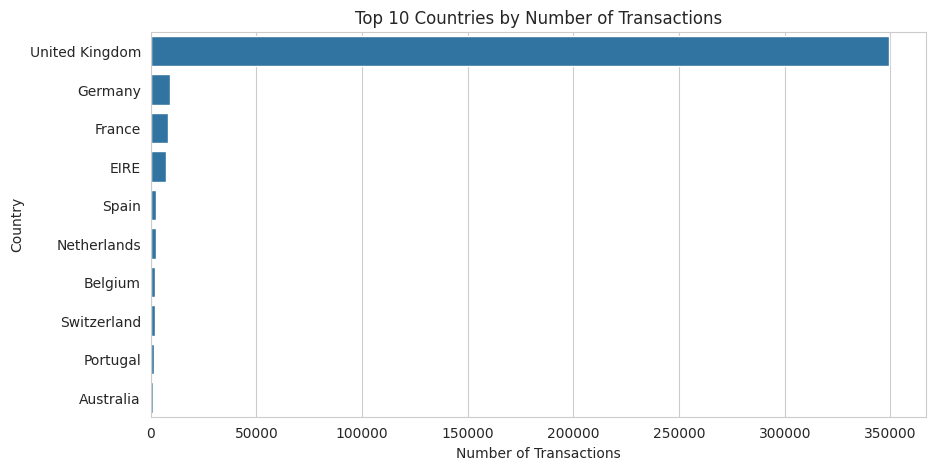

In [8]:
top_countries = data["Country"].value_counts().head(10)

plt.figure(figsize=(10,5))
sns.barplot(x=top_countries.values, y=top_countries.index)
plt.title("Top 10 Countries by Number of Transactions")
plt.xlabel("Number of Transactions")
plt.show()

Rows: 392692
Min date: 2010-12-01 08:26:00
Max date: 2011-12-09 12:50:00

Months found: 13
InvoiceDate
2010-12-31     570422.730
2011-01-31     568101.310
2011-02-28     446084.920
2011-03-31     594081.760
2011-04-30     468374.331
2011-05-31     677355.150
2011-06-30     660046.050
2011-07-31     598962.901
2011-08-31     644051.040
2011-09-30     950690.202
2011-10-31    1035642.450
2011-11-30    1156205.610
2011-12-31     517190.440
Freq: ME, Name: TotalPrice, dtype: float64


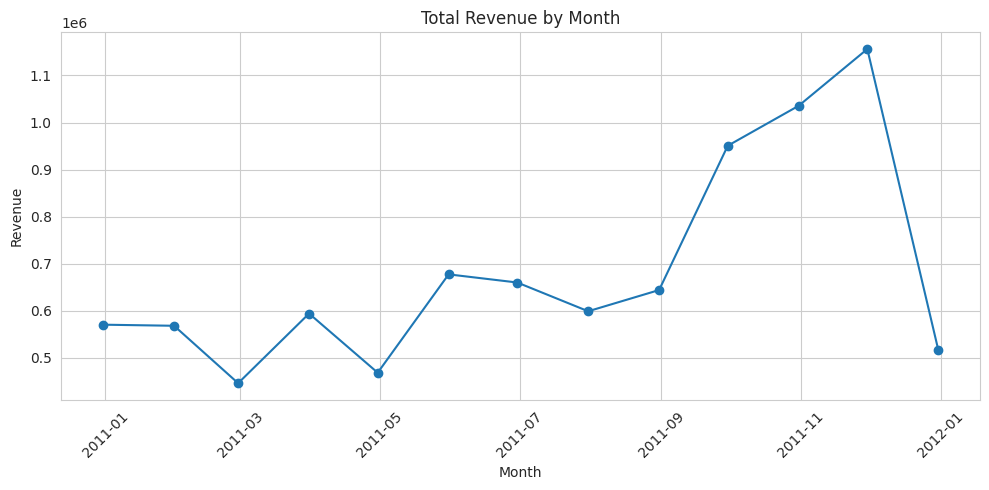

In [9]:
print("Rows:", len(data))
print("Min date:", data["InvoiceDate"].min())
print("Max date:", data["InvoiceDate"].max())

monthly_sales = data.set_index("InvoiceDate").resample("ME")["TotalPrice"].sum()
print("\nMonths found:", len(monthly_sales))
print(monthly_sales)

plt.figure(figsize=(10,5))
plt.plot(monthly_sales.index, monthly_sales.values, marker="o")
plt.title("Total Revenue by Month")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

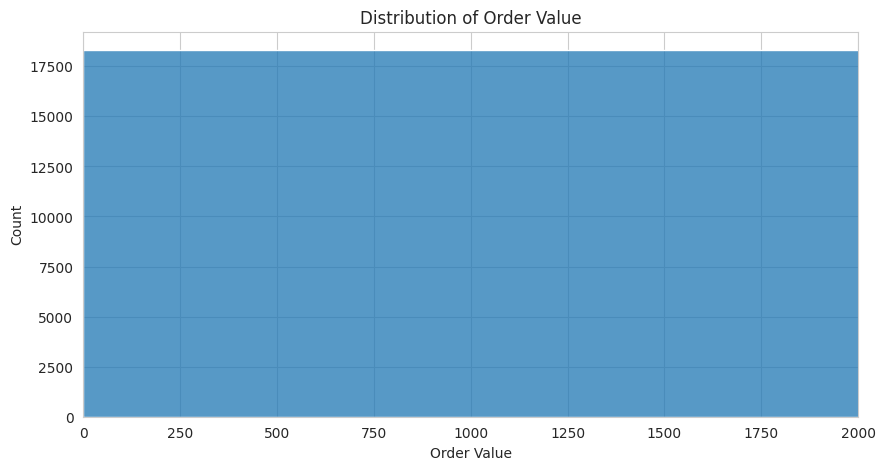

In [10]:
order_totals = data.groupby("InvoiceNo")["TotalPrice"].sum()

plt.figure(figsize=(10,5))
sns.histplot(order_totals, bins=50)
plt.title("Distribution of Order Value")
plt.xlabel("Order Value")
plt.xlim(0, 2000)   # zoom in
plt.show()

### 1.4 RFM Feature Engineering

In [11]:
last_date = data["InvoiceDate"].max() + pd.Timedelta(days=1)

last_purchase = data.groupby("CustomerID")["InvoiceDate"].max().reset_index()
last_purchase.columns = ["CustomerID", "LastPurchaseDate"]
last_purchase["Recency"] = (last_date - last_purchase["LastPurchaseDate"]).dt.days

frequency = data.groupby("CustomerID")["InvoiceNo"].nunique().reset_index()
frequency.columns = ["CustomerID", "Frequency"]

monetary = data.groupby("CustomerID")["TotalPrice"].sum().reset_index()
monetary.columns = ["CustomerID", "Monetary"]

rfm = last_purchase[["CustomerID", "Recency"]]
rfm = rfm.merge(frequency, on="CustomerID")
rfm = rfm.merge(monetary, on="CustomerID")

print("RFM table shape:", rfm.shape)
rfm.head()

RFM table shape: (4338, 4)


,CustomerID,Recency,Frequency,Monetary
0,12346,326,1,77183.60
1,12347,2,7,4310.00
2,12348,75,4,1797.24
3,12349,19,1,1757.55
4,12350,310,1,334.40


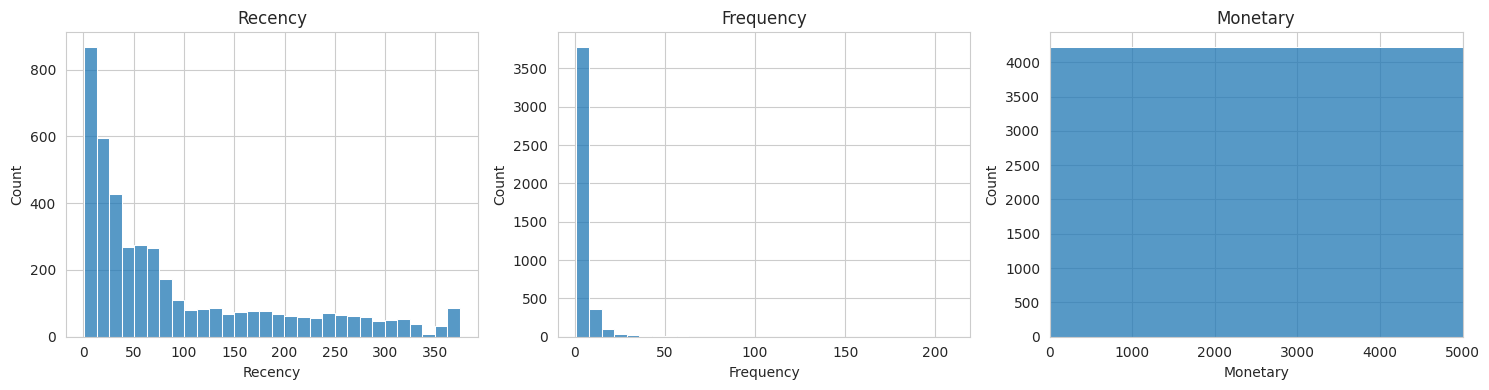

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(15,4))
sns.histplot(rfm["Recency"], bins=30, ax=axes[0])
axes[0].set_title("Recency")
sns.histplot(rfm["Frequency"], bins=30, ax=axes[1])
axes[1].set_title("Frequency")
sns.histplot(rfm["Monetary"], bins=30, ax=axes[2])
axes[2].set_xlim(0, 5000)
axes[2].set_title("Monetary")

plt.tight_layout()
plt.show()

### 1.5 Custom Features

In [13]:
# Feature 1: Average days between orders
order_dates = data.groupby(["CustomerID", "InvoiceNo"])["InvoiceDate"].min().reset_index()
order_dates = order_dates.sort_values(["CustomerID", "InvoiceDate"])

order_dates["gap"] = order_dates.groupby("CustomerID")["InvoiceDate"].diff().dt.days
avg_gap = order_dates.groupby("CustomerID")["gap"].mean().reset_index()
avg_gap.columns = ["CustomerID", "AvgDaysBetweenOrders"]

avg_gap.head()

,CustomerID,AvgDaysBetweenOrders
0,12346,NaN
1,12347,60.333333
2,12348,94.000000
3,12349,NaN
4,12350,NaN


In [14]:
# Feature 2: Weekend purchase ratio
data["IsWeekend"] = data["InvoiceDate"].dt.dayofweek >= 5   # Saturday=5, Sunday=6

weekend_ratio = data.groupby("CustomerID")["IsWeekend"].mean().reset_index()
weekend_ratio.columns = ["CustomerID", "WeekendRatio"]

weekend_ratio.head()

,CustomerID,WeekendRatio
0,12346,0.000000
1,12347,0.000000
2,12348,0.096774
3,12349,0.000000
4,12350,0.000000


In [15]:
# Feature 3: Country ko target encoding se numeric feature bana rahe hain
country_avg = data.groupby("Country")["TotalPrice"].mean()
customer_country = data.groupby("CustomerID")["Country"].agg(lambda x: x.value_counts().index[0]).reset_index()
customer_country["CountryEncoded"] = customer_country["Country"].map(country_avg)

customer_country.head()

,CustomerID,Country,CountryEncoded
0,12346,United Kingdom,20.861862
1,12347,Iceland,23.681319
2,12348,Finland,32.913985
3,12349,Italy,23.064960
4,12350,Norway,33.767918


### 1.6 Final Feature Table

In [16]:
final_table = rfm.merge(avg_gap, on="CustomerID", how="left")
final_table = final_table.merge(weekend_ratio, on="CustomerID", how="left")
final_table = final_table.merge(customer_country[["CustomerID", "CountryEncoded"]], on="CustomerID", how="left")

print("Final table shape:", final_table.shape)
print("\nMissing values:")
print(final_table.isnull().sum())

final_table.head()

Final table shape: (4338, 7)

Missing values:
CustomerID                 0
Recency                    0
Frequency                  0
Monetary                   0
AvgDaysBetweenOrders    1493
WeekendRatio               0
CountryEncoded             0
dtype: int64


,CustomerID,Recency,Frequency,Monetary,AvgDaysBetweenOrders,WeekendRatio,CountryEncoded
0,12346,326,1,77183.60,NaN,0.000000,20.861862
1,12347,2,7,4310.00,60.333333,0.000000,23.681319
2,12348,75,4,1797.24,94.000000,0.096774,32.913985
3,12349,19,1,1757.55,NaN,0.000000,23.064960
4,12350,310,1,334.40,NaN,0.000000,33.767918


In [17]:
num_cols = ["Recency", "Frequency", "Monetary", "AvgDaysBetweenOrders", "WeekendRatio", "CountryEncoded"]

num_pipeline = Pipeline([
    ("fill_missing", SimpleImputer(strategy="median")),
    ("scale", StandardScaler())
])

preprocessor = ColumnTransformer([
    ("numbers", num_pipeline, num_cols)
])

final_pipeline = Pipeline([
    ("prep", preprocessor)
])

final_data = final_pipeline.fit_transform(final_table)

print("Final transformed data shape:", final_data.shape)
print(final_data[:5])

Final transformed data shape: (4338, 6)
[[ 2.33457414 -0.4250965   8.36301037 -0.23371846 -0.4723229  -0.1415106 ]
 [-0.90534032  0.3544168   0.2516989  -0.09749771 -0.4723229   0.19730116]
 [-0.17535959 -0.03533985 -0.02798783  0.52787934 -0.12613866  1.30678286]
 [-0.73534481 -0.4250965  -0.03240559 -0.23371846 -0.4723229   0.12323392]
 [ 2.17457836 -0.4250965  -0.19081155 -0.23371846 -0.4723229   1.40939919]]


In [18]:
final_table.to_csv("customer_features.csv", index=False)
np.save("customer_features_scaled.npy", final_data)

print("Saved: customer_features.csv and customer_features_scaled.npy")

Saved: customer_features.csv and customer_features_scaled.npy


## Phase 2: Customer Segmentation (Clustering)


### 2.1 Prepare Clustering Data

In [19]:
df = final_table.copy()
df["AvgDaysBetweenOrders"] = df["AvgDaysBetweenOrders"].fillna(
    df["AvgDaysBetweenOrders"].median()
)

print(df.isnull().sum())
df.head()

CustomerID              0
Recency                 0
Frequency               0
Monetary                0
AvgDaysBetweenOrders    0
WeekendRatio            0
CountryEncoded          0
dtype: int64


,CustomerID,Recency,Frequency,Monetary,AvgDaysBetweenOrders,WeekendRatio,CountryEncoded
0,12346,326,1,77183.60,53.000000,0.000000,20.861862
1,12347,2,7,4310.00,60.333333,0.000000,23.681319
2,12348,75,4,1797.24,94.000000,0.096774,32.913985
3,12349,19,1,1757.55,53.000000,0.000000,23.064960
4,12350,310,1,334.40,53.000000,0.000000,33.767918


In [20]:
X = df[
    [
        "Recency",
        "Frequency",
        "Monetary",
        "AvgDaysBetweenOrders",
        "WeekendRatio",
        "CountryEncoded"
    ]
]

X.head()

,Recency,Frequency,Monetary,AvgDaysBetweenOrders,WeekendRatio,CountryEncoded
0,326,1,77183.60,53.000000,0.000000,20.861862
1,2,7,4310.00,60.333333,0.000000,23.681319
2,75,4,1797.24,94.000000,0.096774,32.913985
3,19,1,1757.55,53.000000,0.000000,23.064960
4,310,1,334.40,53.000000,0.000000,33.767918


In [21]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("Feature Scaling Completed Successfully!")

Feature Scaling Completed Successfully!


In [22]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

print("Explained Variance Ratio:")
print(pca.explained_variance_ratio_)

Explained Variance Ratio:
[0.28749408 0.18449562]


### 2.2 Finding Optimal Number of Clusters (Elbow Method)

In [23]:
wcss = []

for k in range(2, 11):
    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    model.fit(X_scaled)
    wcss.append(model.inertia_)

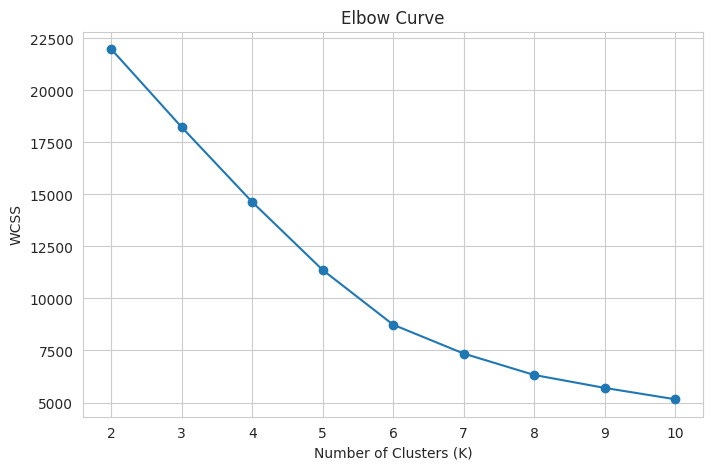

In [24]:
plt.figure(figsize=(8,5))
plt.plot(range(2,11), wcss, marker='o')
plt.title("Elbow Curve")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")
plt.grid(True)
plt.show()

### 2.3 KMeans Clustering (k=6)

In [25]:
kmeans = KMeans(
    n_clusters=6,
    random_state=42,
    n_init=10
)

df["Cluster"] = kmeans.fit_predict(X_scaled)
df.head()

,CustomerID,Recency,Frequency,Monetary,AvgDaysBetweenOrders,WeekendRatio,CountryEncoded,Cluster
0,12346,326,1,77183.60,53.000000,0.000000,20.861862,4
1,12347,2,7,4310.00,60.333333,0.000000,23.681319,1
2,12348,75,4,1797.24,94.000000,0.096774,32.913985,1
3,12349,19,1,1757.55,53.000000,0.000000,23.064960,1
4,12350,310,1,334.40,53.000000,0.000000,33.767918,4


In [26]:
score = silhouette_score(X_scaled, df["Cluster"])

print("Silhouette Score:", round(score, 3))

Silhouette Score: 0.447


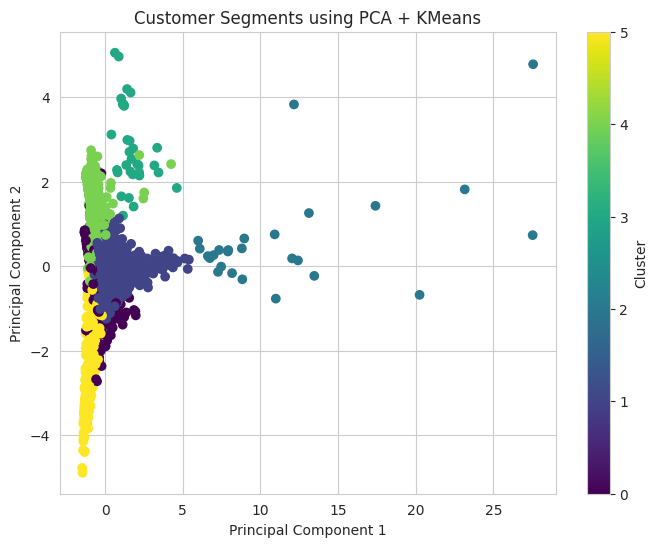

In [27]:
plt.figure(figsize=(8,6))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=df["Cluster"],
    cmap="viridis"
)

plt.title("Customer Segments using PCA + KMeans")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.colorbar(label="Cluster")
plt.grid(True)
plt.show()

In [28]:
cluster_summary = df.groupby("Cluster").mean(numeric_only=True)
cluster_summary

,Recency,Frequency,Monetary,AvgDaysBetweenOrders,WeekendRatio,CountryEncoded
Cluster,,,,,,
0,97.201313,2.888403,886.989389,55.879824,0.853593,21.072227
1,40.168254,5.188492,2072.929636,51.527893,0.051084,21.378829
2,6.038462,66.423077,85826.078077,14.238205,0.052527,29.639129
3,104.424242,3.696970,3552.522121,66.899711,0.100918,109.586139
4,250.826652,1.567714,658.386978,52.146968,0.009747,21.299140
5,54.517150,2.218997,795.962058,206.854881,0.106214,21.257095


### 2.4 Customer-level Anomaly Detection

In [29]:
iso = IsolationForest(
    contamination=0.01,   # Detect top 1% anomalies
    random_state=42
)

df["Anomaly"] = iso.fit_predict(X_scaled)

print(df["Anomaly"].value_counts())

Anomaly
 1    4294
-1      44
Name: count, dtype: int64


In [30]:
anomalies = df[df["Anomaly"] == -1]

print("Number of Anomalous Customers:", len(anomalies))
anomalies.head(10)

Number of Anomalous Customers: 44


,CustomerID,Recency,Frequency,Monetary,AvgDaysBetweenOrders,WeekendRatio,CountryEncoded,Cluster,Anomaly
33,12386,338,2,401.90,29.000000,0.000000,117.234386,3,-1
34,12388,16,6,2780.66,61.800000,0.220000,117.234386,3,-1
55,12415,24,21,124914.53,15.150000,0.000000,117.234386,2,-1
62,12424,163,2,1760.96,0.000000,0.000000,117.234386,3,-1
69,12431,36,15,6419.95,23.714286,0.128205,117.234386,3,-1
73,12435,80,2,7829.89,188.000000,0.000000,49.882474,5,-1
111,12483,17,8,2484.98,45.285714,0.213333,85.261844,3,-1
236,12638,33,1,671.69,53.000000,1.000000,85.261844,3,-1
324,12744,52,7,21279.29,44.000000,0.000000,95.852658,3,-1
326,12748,1,209,33053.19,1.432692,0.154352,20.861862,2,-1


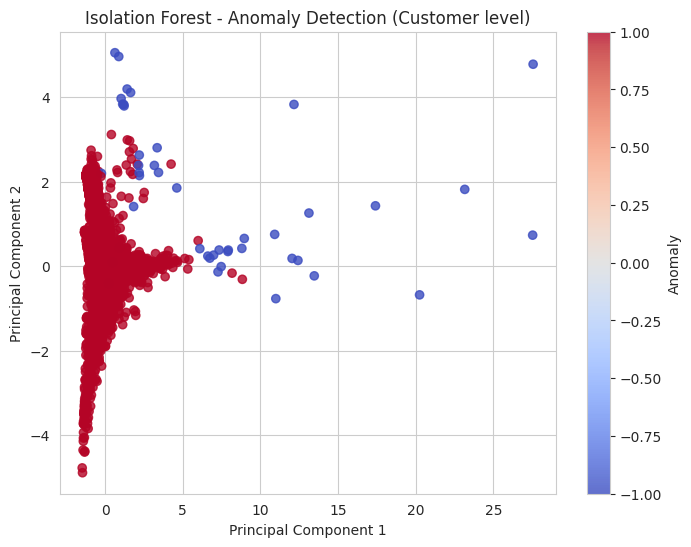

In [31]:
plt.figure(figsize=(8,6))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=df["Anomaly"],
    cmap="coolwarm",
    alpha=0.8
)

plt.title("Isolation Forest - Anomaly Detection (Customer level)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.colorbar(label="Anomaly")
plt.grid(True)
plt.show()

In [32]:
df.to_csv("customer_segmentation_output.csv", index=False)

print("Customer segmentation output saved successfully!")

Customer segmentation output saved successfully!


## Phase 3: Anomaly Detection & Sales Forecasting



### 3.1 Transaction-level Anomaly Detection

In [33]:
iso_features = data[["Quantity", "UnitPrice", "TotalPrice"]]

iso_model = IsolationForest(contamination=0.01, random_state=42)
data["anomaly"] = iso_model.fit_predict(iso_features)   # -1 = anomaly, 1 = normal

n_anomalies = (data["anomaly"] == -1).sum()
print("Total anomalies found:", n_anomalies, "out of", len(data), "rows")

Total anomalies found: 3922 out of 392692 rows


In [34]:
anomalies = data[data["anomaly"] == -1]
anomalies[["Quantity", "UnitPrice", "TotalPrice"]].describe()

,Quantity,UnitPrice,TotalPrice
count,3922.000000,3922.000000,3922.000000
mean,281.256502,30.691402,527.831181
std,1777.633855,218.850102,3061.718838
min,1.000000,0.040000,17.280000
25%,60.000000,1.250000,212.120000
50%,192.000000,2.550000,306.000000
75%,288.000000,7.400000,483.840000
max,80995.000000,8142.750000,168469.600000


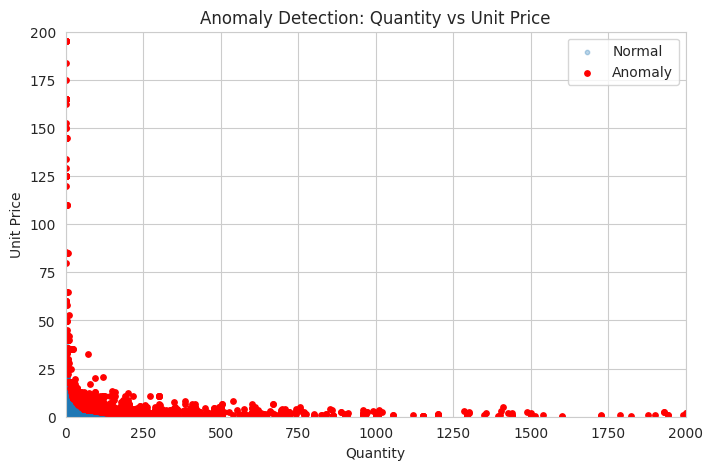

In [35]:
plt.figure(figsize=(8,5))
normal_points = data[data["anomaly"] == 1]
anomaly_points = data[data["anomaly"] == -1]

plt.scatter(normal_points["Quantity"], normal_points["UnitPrice"],
            alpha=0.3, label="Normal", s=10)
plt.scatter(anomaly_points["Quantity"], anomaly_points["UnitPrice"],
            color="red", label="Anomaly", s=15)

plt.xlim(0, 2000)
plt.ylim(0, 200)
plt.xlabel("Quantity")
plt.ylabel("Unit Price")
plt.title("Anomaly Detection: Quantity vs Unit Price")
plt.legend()
plt.show()

In [36]:
clean_data = data[data["anomaly"] == 1]
print("Clean data shape (without anomalies):", clean_data.shape)

Clean data shape (without anomalies): (388770, 11)


### 3.2 Daily Sales Time Series

In [37]:
daily_sales = clean_data.set_index("InvoiceDate").resample("D")["Quantity"].sum()
daily_sales = daily_sales.asfreq("D").fillna(0)

print("Number of days:", len(daily_sales))
daily_sales.head(10)

Number of days: 374


,Quantity
InvoiceDate,
2010-12-01,19276
2010-12-02,22003
2010-12-03,9644
2010-12-04,0
2010-12-05,14675
2010-12-06,14169
2010-12-07,11012
2010-12-08,18721
2010-12-09,13025


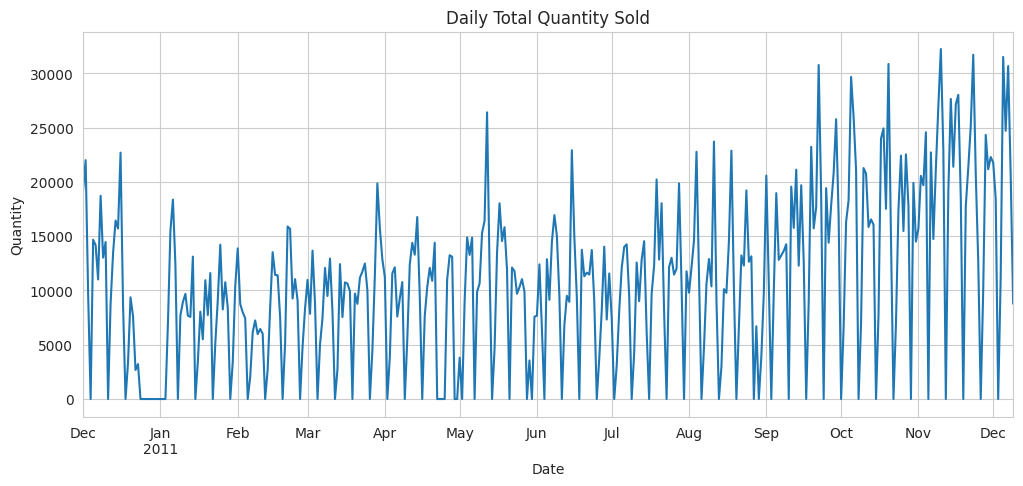

In [38]:
plt.figure(figsize=(12,5))
daily_sales.plot()
plt.title("Daily Total Quantity Sold")
plt.xlabel("Date")
plt.ylabel("Quantity")
plt.show()

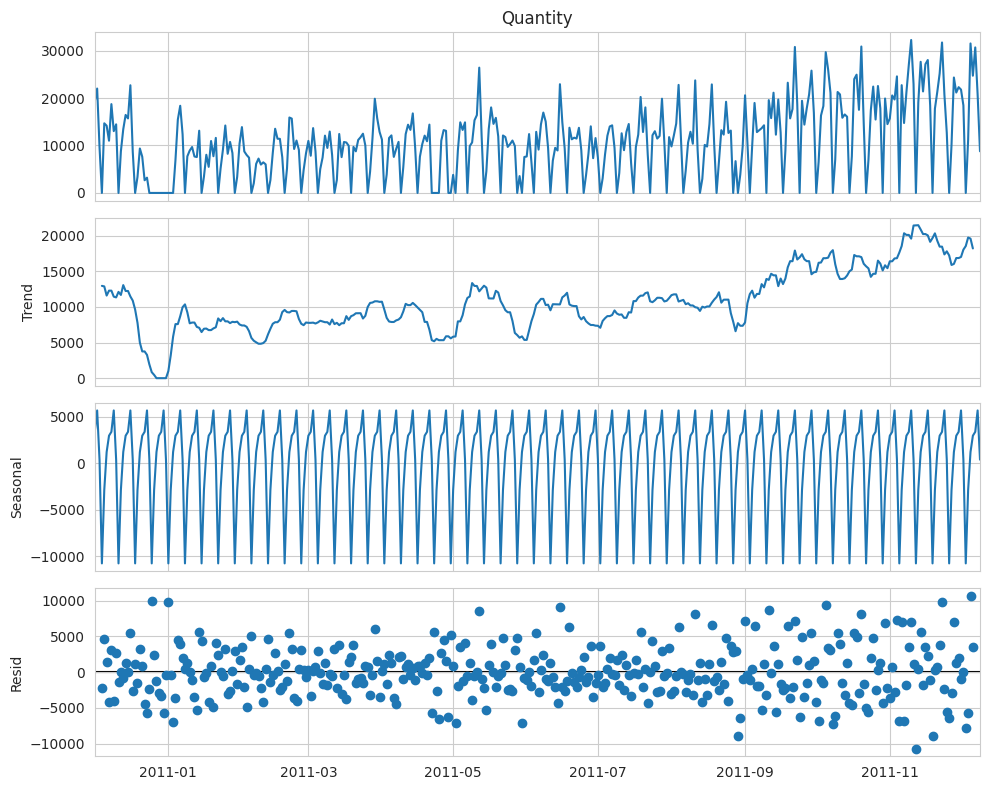

In [39]:
decomposition = seasonal_decompose(daily_sales, model="additive", period=7)

fig = decomposition.plot()
fig.set_size_inches(10, 8)
plt.tight_layout()
plt.show()

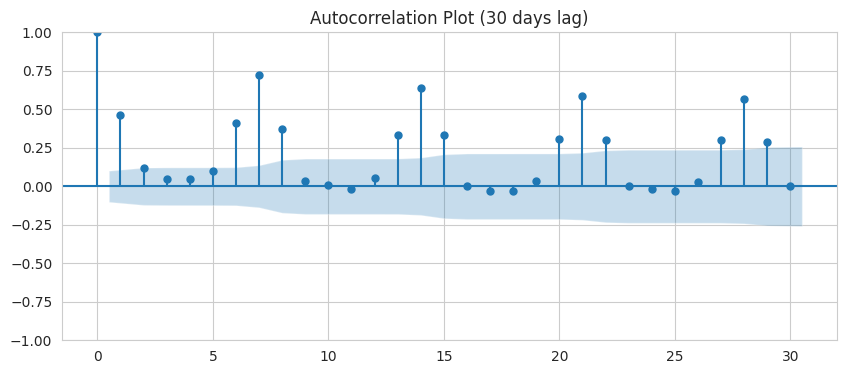

In [40]:
fig, ax = plt.subplots(figsize=(10,4))
plot_acf(daily_sales, lags=30, ax=ax)
plt.title("Autocorrelation Plot (30 days lag)")
plt.show()

### 3.3 Train-Test Split

In [41]:
train = daily_sales[:-14]
test = daily_sales[-14:]

print("Train size:", len(train))
print("Test size:", len(test))

Train size: 360
Test size: 14


### 3.4 ARIMA Forecasting

In [42]:
arima_model = ARIMA(train, order=(2,1,2))
arima_fit = arima_model.fit()

arima_forecast = arima_fit.forecast(steps=14)
print(arima_forecast)

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


2011-11-26    14020.739133
2011-11-27    18354.606999
2011-11-28    21694.999537
2011-11-29    22368.151778
2011-11-30    21077.472598
2011-12-01    19460.041632
2011-12-02    18667.066304
2011-12-03    18847.577953
2011-12-04    19477.821067
2011-12-05    19973.212896
2011-12-06    20080.261740
2011-12-07    19895.718390
2011-12-08    19658.211195
2011-12-09    19538.888034
Freq: D, Name: predicted_mean, dtype: float64


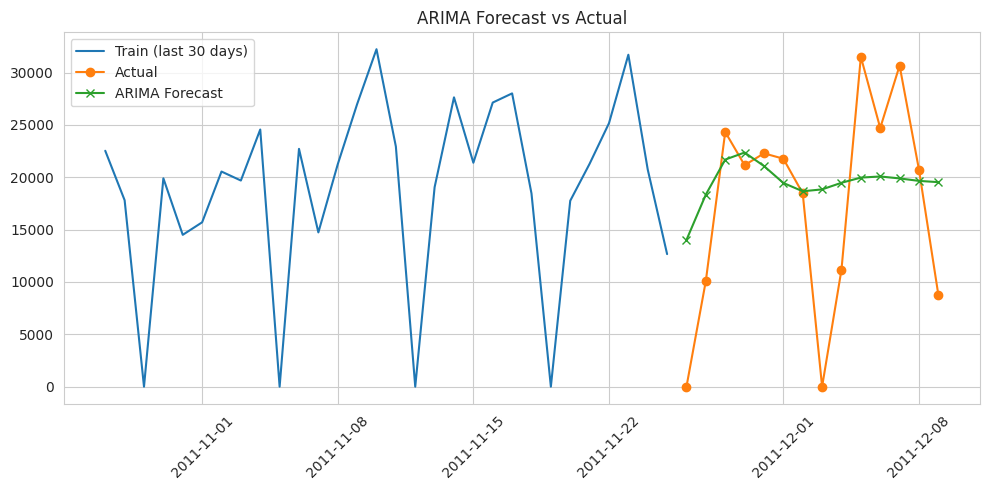

In [43]:
plt.figure(figsize=(10,5))
plt.plot(train.index[-30:], train.values[-30:], label="Train (last 30 days)")
plt.plot(test.index, test.values, label="Actual", marker="o")
plt.plot(test.index, arima_forecast.values, label="ARIMA Forecast", marker="x")
plt.legend()
plt.title("ARIMA Forecast vs Actual")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 3.5 Prophet Forecasting

In [44]:
prophet_df = train.reset_index()
prophet_df.columns = ["ds", "y"]

prophet_model = Prophet()
prophet_model.fit(prophet_df)

future = prophet_model.make_future_dataframe(periods=14)
prophet_forecast = prophet_model.predict(future)

prophet_pred = prophet_forecast.set_index("ds")["yhat"][-14:]
prophet_pred

INFO:prophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


,yhat
ds,
2011-11-26,7901.059402
2011-11-27,15754.510289
2011-11-28,19343.481229
2011-11-29,21394.156180
2011-11-30,22073.126396
2011-12-01,24456.591412
2011-12-02,19072.223079
2011-12-03,8354.066476
2011-12-04,16207.517364


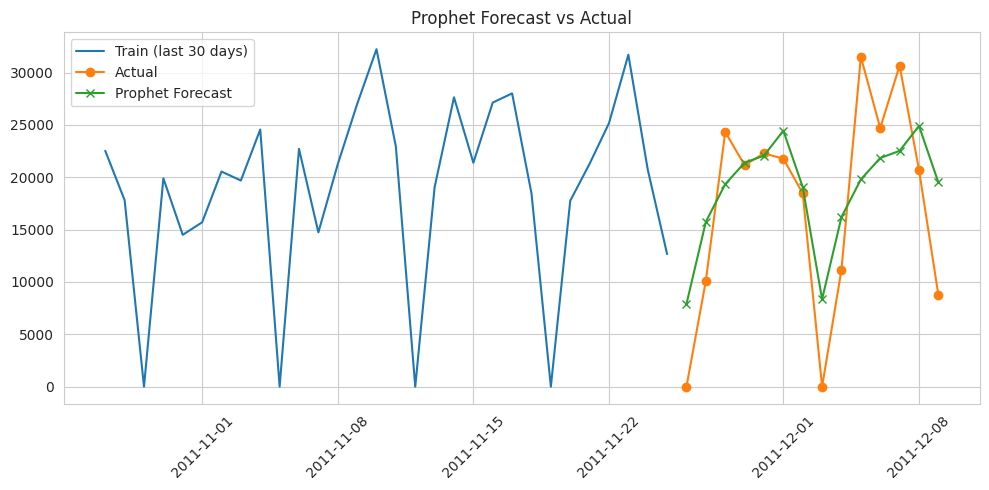

In [45]:
plt.figure(figsize=(10,5))
plt.plot(train.index[-30:], train.values[-30:], label="Train (last 30 days)")
plt.plot(test.index, test.values, label="Actual", marker="o")
plt.plot(test.index, prophet_pred.values, label="Prophet Forecast", marker="x")
plt.legend()
plt.title("Prophet Forecast vs Actual")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 3.6 Model Comparison

In [46]:
def safe_mape(actual, predicted):
    actual = np.array(actual)
    predicted = np.array(predicted)
    mask = actual != 0
    return np.mean(np.abs((actual[mask] - predicted[mask]) / actual[mask])) * 100

# ARIMA scores
arima_rmse = np.sqrt(mean_squared_error(test, arima_forecast))
arima_mape = safe_mape(test.values, arima_forecast.values)

# Prophet scores
prophet_rmse = np.sqrt(mean_squared_error(test, prophet_pred))
prophet_mape = safe_mape(test.values, prophet_pred.values)

results = pd.DataFrame({
    "Model": ["ARIMA", "Prophet"],
    "RMSE": [arima_rmse, prophet_rmse],
    "MAPE (%)": [arima_mape, prophet_mape]
})

results

,Model,RMSE,MAPE (%)
0,ARIMA,8829.927493,33.979169
1,Prophet,6361.806090,29.741359


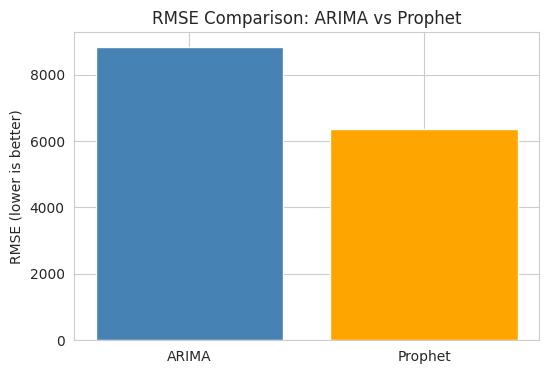

In [47]:
plt.figure(figsize=(6,4))
plt.bar(results["Model"], results["RMSE"], color=["steelblue", "orange"])
plt.title("RMSE Comparison: ARIMA vs Prophet")
plt.ylabel("RMSE (lower is better)")
plt.show()